In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"

In [44]:
warmup_iter = 2
xlow = 4000
xhi = 4500

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_3",
]

plan_data = {
    "Estimate": {},
    "Measure": {},
    "MKL_OUT_OF_PLACE": {},
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_type = data["plan_type"]
        plan_size = data["plan_size"]
        if plan_size < xlow or plan_size > xhi:
            return
        time = np.average(data["timings"][warmup_iter:])
        plan_data[plan_type][plan_size] = time
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [45]:
plot_data = {}
for plan_type in plan_data.keys():
    name = plan_type
    plan_sizes = sorted(plan_data[plan_type].keys())
    times = [plan_data[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

In [47]:
values = set()
for i in range(0, 13):
    for j in range(0, 9):
        for k in range(0, 9):
            for l in range(0, 9):
                for n in range(0, 4):
                    for m in range(0, 4):
                            v = 2**i * 3**j * 5**k * 7**l * 11**n * 13**m
                            if v >= xlow and v <= xhi :
                                values.add(v)
sv = sorted(values)

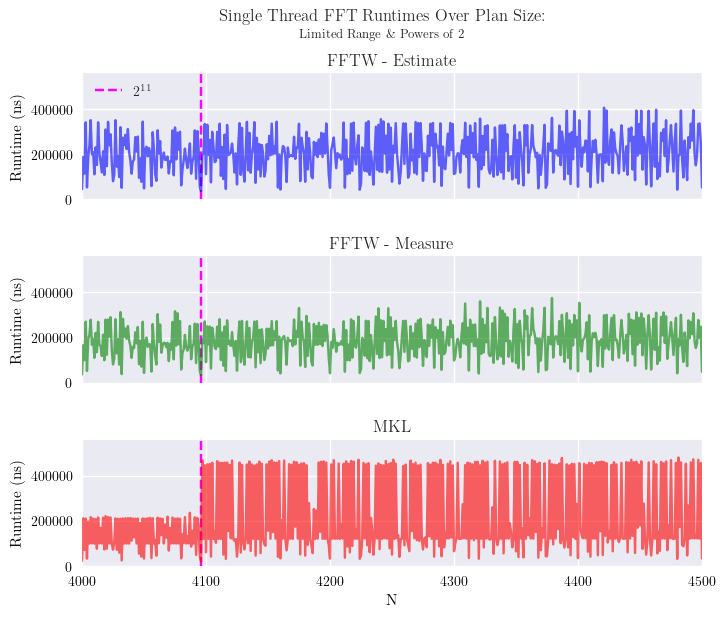

In [62]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])

#for base in [2, 3, 5, 7]:
for base in [2]:
    p = base;
    i = 0;
    while p <= xhi:
        if p > xlow:
            ax_1.axvline(x = p, linestyle = "--", label = f"${base}^{{{i}}}$", color='magenta')
            ax_2.axvline(x = p, linestyle = "--", label = f"${base}^{{{i}}}$", color='magenta')
            ax_3.axvline(x = p, linestyle = "--", label = f"${base}^{{{i}}}$", color='magenta')  
        i += 1
        p *= 2
    

ylow = 0
yhi = 560000
plan_type = "Estimate"
ax_1.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_ylim(ylow, yhi)
ax_1.set_xlim(xlow, xhi)
ax_1.legend(loc='upper left')

plan_type = "Measure"
ax_2.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_ylim(ylow, yhi)
ax_2.set_xlim(xlow, xhi)

plan_type = "MKL_OUT_OF_PLACE"
ax_3.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="red",
    alpha = 0.6
)
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_xlabel("N")
ax_3.set_title("MKL")
ax_3.set_ylim(ylow, yhi)
ax_3.set_xlim(xlow, xhi)

fig.suptitle("Single Thread FFT Runtimes Over Plan Size:\n {\small Limited Range \& Powers of 2}")
plt.savefig(f"{output_dir}/limited_range_2.pdf")

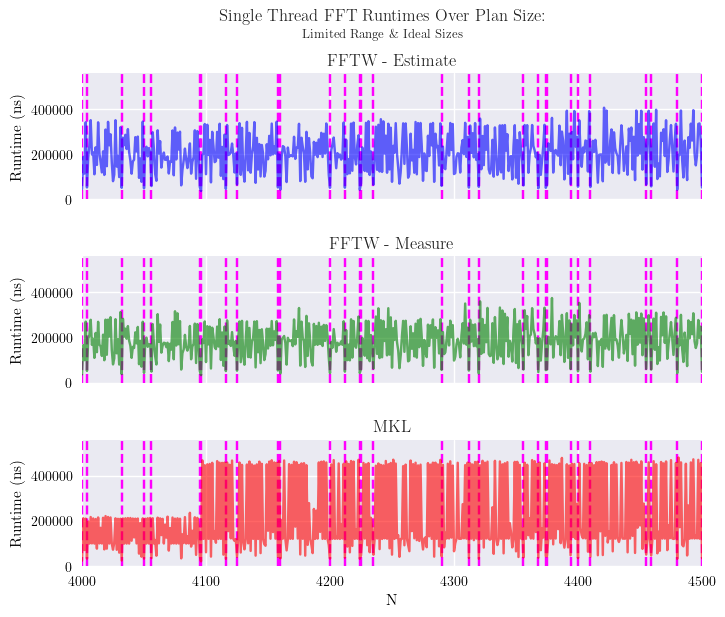

In [63]:
width = 8
height_ratio = 0.8
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 3
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0, 1.0, 1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.45,
    hspace = 0.45,
)
ax_1 = fig.add_subplot(gs1[0, 0])
ax_2 = fig.add_subplot(gs1[1, 0])
ax_3 = fig.add_subplot(gs1[2, 0])


for v in sv:
    ax_1.axvline(x = v, linestyle = "--", color = "magenta")
    ax_2.axvline(x = v, linestyle = "--", color = "magenta")
    ax_3.axvline(x = v, linestyle = "--", color = "magenta")
    

ylow = 0
yhi = 560000
plan_type = "Estimate"
ax_1.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="blue",
    alpha = 0.6
)
ax_1.set_xticklabels([])
ax_1.set_ylabel("Runtime (ns)")
ax_1.set_title("FFTW - Estimate")
ax_1.set_ylim(ylow, yhi)
ax_1.set_xlim(xlow, xhi)

plan_type = "Measure"
ax_2.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="green",
    alpha = 0.6
)
ax_2.set_xticklabels([])
ax_2.set_ylabel("Runtime (ns)")
ax_2.set_title("FFTW - Measure")
ax_2.set_ylim(ylow, yhi)
ax_2.set_xlim(xlow, xhi)

plan_type = "MKL_OUT_OF_PLACE"
ax_3.plot(
    plot_data[plan_type]["plan_sizes"], 
    plot_data[plan_type]["times"], 
    color="red",
    alpha = 0.6
)
ax_3.set_ylabel("Runtime (ns)")
ax_3.set_xlabel("N")
ax_3.set_title("MKL")
ax_3.set_ylim(ylow, yhi)
ax_3.set_xlim(xlow, xhi)

fig.suptitle("Single Thread FFT Runtimes Over Plan Size:\n {\small Limited Range \& Ideal Sizes}")
plt.savefig(f"{output_dir}/limited_range_ideal.pdf")